## Step 1 : Establishing the Dataset Baseline


The first thing I want to do, before moving forward with downstream analysis, is to get a clearer picture of the dataset—how many calls it includes, how many nonsafety cases have been extracted, and whether the labels show a lot of overlap.

Another point I want to look into is whether the dataset's time span is sufficient to provide a representative and meaningful view.

Concretely, this step does three things:

Go through all 99 JSON files in the dataset individually.
Collect all data points from nonsafety_use_cases.
Along the way, the safety_use_cases labels will be collected too, which should help with analyzing any overlap between safe and unsafe cases afterward.

Next, I’ll compute a set of basic metrics, such as the overall volume, how labels look after deduplication, the time span covered by the data, and how it’s distributed across years.


## How to read the output

- **Total files: 99**  
Since all 99 call files loaded without issues, the dataset appears to be complete in terms of files.

- **Total nonsafety cases: 231**  
In total, 231 nonsafety use case records are generated during extraction from the 99 calls. Here, 231 indicates how many entries were pulled out, not how many unique customer needs there are.



- **Unique labels: 228 (98.7%)**  
 This is the most important finding at this stage. Out of 231 nonsafety records, 228 have unique labels, meaning almost every entry is phrased differently.

 In a well-structured analytical dataset, similar or recurring needs would typically be expected to map to a smaller set of reusable labels. Here, the 98.7% uniqueness strongly suggests that the extraction output is preserving surface-level phrasing rather than consolidating related cases into stable concepts.

 This does not mean the extracted records are useless. It means the raw labels should not yet be treated as a reliable taxonomy for aggregation. A normalization step is therefore needed before interpreting frequency counts as evidence of real demand patterns.

- **Date range: 2022-01-06 → 2024-12-20**  
 The dataset spans roughly three years, which is enough to support directional analysis over time.

- **Year distribution: 2022: 30, 2023: 30, 2024: 39**  
Across the years, the number of calls remains largely consistent, except for a slight increase in 2024.  The dataset shows no clear time bias toward any one year, which helps limit the possibility that subsequent findings are largely shaped by just one period.


## One-line takeaway

The key takeaway from this step is the **98.7% label uniqueness**.

This indicates that raw nonsafety labels are better interpreted as noisy extraction outputs than as a stable demand taxonomy. Before getting into any pattern-level insights, it helps to first bring the labels into a more consistent and reusable form.



In [2]:
import json, os, re
from collections import defaultdict, Counter

DATA_DIR = "analytics-internship-main/safety-nonsafety"

files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith(".json")])
calls = []
nonsafety_cases = []
safety_labels_all = set()
year_counts = Counter()

for fname in files:
    with open(os.path.join(DATA_DIR, fname)) as f:
        d = json.load(f)
    yr = d.get("start_time", "")[:4]
    if yr:
        year_counts[yr] += 1
    calls.append({"file": fname, "start_time": d.get("start_time",""), "title": d.get("meeting_title","")})
    ext = d.get("extraction", {})
    for uc in ext.get("safety_use_cases", []):
        safety_labels_all.add(uc.get("label","").lower().strip())
    for uc in ext.get("nonsafety_use_cases", []):
        nonsafety_cases.append({
            "file": fname,
            "label": uc.get("label",""),
            "label_lower": uc.get("label","").lower().strip(),
            "speakers": [ev.get("speaker","") for ev in uc.get("evidence",[])],
            "evidence_count": len(uc.get("evidence",[])),
        })

total = len(nonsafety_cases)
unique_labels = len(set(c["label_lower"] for c in nonsafety_cases))
sorted_times = sorted(c["start_time"] for c in calls)

print("=== STEP 1: BASELINE ===")
print(f"Total files:           {len(files)}")
print(f"Total nonsafety cases: {total}")
print(f"Unique labels:         {unique_labels}  ({unique_labels/total*100:.1f}%)")
print(f"Date range:            {sorted_times[0][:10]}  →  {sorted_times[-1][:10]}")
print(f"Year distribution:     {dict(sorted(year_counts.items()))}")

=== STEP 1: BASELINE ===
Total files:           99
Total nonsafety cases: 231
Unique labels:         228  (98.7%)
Date range:            2022-01-06  →  2024-12-20
Year distribution:     {'2022': 30, '2023': 30, '2024': 39}


## Step 2 — Classifying speaker origin

### Why this step matters

Each nonsafety use case includes supporting evidence, and each evidence quote has a `speaker` field.  
At this stage, I want to separate the extracted use case itself from the source of the evidence behind it.


This is an important distinction to make, as evidence from different origins can imply very different things.
There is a meaningful difference between a use case raised solely by Voxel and one introduced independently by the customer.
If a use case is only brought up by Voxel, I can’t rely on this dataset alone to decide whether it points to a true customer need or is more a product of Voxel’s interpretation.


### What this step does

I use speaker email domains to classify each nonsafety case into one of four buckets:

- **`voxel_only`**: all evidence speakers are from `@voxelai.com`
- **`customer_only`**: none of the evidence speakers are from `@voxelai.com`
- **`mixed`**: both Voxel and non-Voxel speakers appear
- **`no_evidence`**: the case has no supporting evidence

I also added three simple flags that are used later in scoring:

- **`customer_only_flag`**: marks the strongest direct customer-demand signal
- **`any_customer`**: true for both `customer_only` and `mixed`
- **`multi_evidence`**: true when a case has at least 2 supporting evidence items

### How to read the output

- **`voxel_only`: 74 (32.0%)**  
  This highlights an important limitation in the dataset. About one-third of nonsafety cases are supported only by Voxel speakers, so these cases cannot be directly verified as customer-articulated demand from the available evidence alone.

 That does not mean these use cases are invalid. It only means the evidence does not show the customer stating them directly.


- **`customer_only`: 77 (33.3%)**  
In this dataset, these are the most straightforward and transparent signals of what customers actually need.  Everything supporting this point originates from the customer alone, with no participation from Voxel.



- **`mixed`: 80 (34.6%)**  
  These cases do include customer evidence, which makes them useful, but Voxel is also part of the conversation. That means they are less cleanly attributable to customer-originated demand than `customer_only`.

  Importantly, **`mixed` should not be interpreted as automatically customer-led**. It simply means customer participation is present in the evidence.

- **`no_evidence`: 0 (0.0%)**  
  Every nonsafety case has at least some supporting evidence, so speaker-origin analysis can be applied across the full dataset.

### One-line takeaway

This step shows a source-of-evidence problem: **since the supporting evidence is limited to statements made by Voxel, it is not possible to determine directly whether 32% of the nonsafety cases truly reflect customer demand.**.

That is why the later analysis keeps `customer_only` and `any_customer` separate, rather than collapsing them into a single customer-demand bucket.

In [3]:
def is_voxel(speaker):
    return "voxelai.com" in speaker.lower()

def classify_origin(speakers):
    if not speakers:
        return "no_evidence"
    voxel = [s for s in speakers if is_voxel(s)]
    if len(voxel) == len(speakers):
        return "voxel_only"
    elif len(voxel) == 0:
        return "customer_only"
    return "mixed"

for c in nonsafety_cases:
    c["origin"] = classify_origin(c["speakers"])

origin_counts = Counter(c["origin"] for c in nonsafety_cases)

print("=== STEP 2: SPEAKER ORIGIN ===")
for k in ["voxel_only", "customer_only", "mixed", "no_evidence"]:
    v = origin_counts.get(k, 0)
    print(f"  {k:<18} {v:>4}  ({v/total*100:.1f}%)")

for c in nonsafety_cases:
    c["customer_only_flag"] = c["origin"] == "customer_only"
    c["any_customer"]       = c["origin"] in ("customer_only", "mixed")
    c["multi_evidence"]     = c["evidence_count"] >= 2

=== STEP 2: SPEAKER ORIGIN ===
  voxel_only           74  (32.0%)
  customer_only        77  (33.3%)
  mixed                80  (34.6%)
  no_evidence           0  (0.0%)


## Step 3–4 — Checking Bucket Separation and Estimating Customer Coverage

### Why these two checks belong together

As a first step before the next part of the analysis, I want to address two questions that are closely linked: 


1. **Are the safety and nonsafety buckets cleanly separated at the label level?**
2. **How much customer coverage is actually visible behind the nonsafety signals?**

Although these two checks are different, they are ultimately aimed at the same practical issue: the data cannot be interpreted simply by looking at the surface-level number of nonsafety cases.

A nonsafety case may look more meaningful than it really is for at least two reasons:

- It may not be cleanly separable from the safety bucket
- This pattern may come from multiple interactions with a single organization, not from broad demand across different customers.



## Step 3 — Safety / Nonsafety Exact Overlap

### What this check does

I compare all nonsafety labels against all safety labels using an exact string match after lowercasing and stripping whitespace.

This is intentionally conservative. I use exact matching because it is easy to defend and does not depend on any fuzzy similarity threshold.

### How to read the output

- **Exact overlap labels: 28**  
  There are 28 label strings that appear in both the safety and nonsafety buckets.

- **Cases with overlap flag: 28**  
  These correspond to 28 non-safety cases. Since the two numbers are the same, each overlapping label appears only once in the nonsafety set.

### Why it matters

This is direct evidence that the boundary between the two buckets is not fully clean. These overlapping cases should not automatically be treated as clearly separate adjacent opportunities.

At a minimum, the extraction pipeline is not consistently separating some labels across the safety and nonsafety buckets.

This matters especially for themes such as Security / Evidence, where some signals may require extra validation before being interpreted as a distinct nonsafety product direction.

### Step 3 takeaway

The safety / nonsafety boundary is not fully reliable at the label level: **28 exact labels appear in both buckets**, so nonsafety counts cannot automatically be interpreted as purely net-new opportunities.



## Step 4 — Customer Domain Proxy

### What this check does

To get a rough proxy for customer coverage within nonsafety evidence, I extract email domains from the `speaker` field, exclude `@voxelai.com`, and track which domains appear in which files.

From that, I compute:

- How many files contain at least one non-Voxel domain in nonsafety evidence
- How many unique non-Voxel domains appear overall
- How many domains show up in more than one file

### How to read the output

- **Files with ≥1 customer domain: 58 / 99**  
  In 58 of the 99 files, at least one nonsafety evidence quote is associated with a non-Voxel domain.

  This does **not** mean the remaining 41 files had no customer participation. It only means that, within nonsafety evidence, no identifiable non-Voxel domain was captured.

- **Unique customer domains: 47**  
  There are 47 distinct non-Voxel domains observed in the dataset.

  This is only a proxy, not a true account count. One organization may use multiple domains, and multiple domains do not necessarily map perfectly to distinct customer accounts.

- **Domains in >1 file: 11**  
  Eleven domains appear in more than one file, suggesting repeated interactions with at least some organizations, as approximated by domain.

  These repeated domains are useful because they show that some observed signals are not limited to a single file or a single one-off mention.

### Why it matters


Looking only at the number of files does not give a clear picture of how broad the demand actually is. Multiple files may come from the same company, and repeated interactions with that company do not mean the need is common across many different organizations.


This is not a precise account-level metric, but it gives a better-supported approximation of visible customer coverage than a simple file count.



### Step 4 takeaway

Customer coverage is only partially visible from raw files.  
Email domains provide a more grounded proxy than file counts alone, but they still fall short of a true account-level view.


## Combined takeaway

Step 3 shows that **category boundaries are not fully clean**, and Step 4 shows that **customer coverage is only imperfectly observable**.

Overall, these checks help explain why the raw count of nonsafety cases should not be taken at face value. They are better understood as signals rather than a neatly defined list of needs.

In [4]:
# Step 3 — Safety/nonsafety exact overlap
for c in nonsafety_cases:
    c["overlap"] = c["label_lower"] in safety_labels_all

exact_overlap_labels = {c["label_lower"] for c in nonsafety_cases} & safety_labels_all
overlap_cases = sum(1 for c in nonsafety_cases if c["overlap"])

print("=== STEP 3: SAFETY/NONSAFETY OVERLAP ===")
print(f"  Exact overlap labels:    {len(exact_overlap_labels)}")
print(f"  Cases with overlap flag: {overlap_cases}")

# Step 4 — Domain proxy (nonsafety scope only)
domain_to_files = defaultdict(list)

for fname in files:
    with open(os.path.join(DATA_DIR, fname)) as f:
        d = json.load(f)
    file_domains = set()
    for uc in d.get("extraction", {}).get("nonsafety_use_cases", []):
        for ev in uc.get("evidence", []):
            m = re.search(r"@([\w.]+)", ev.get("speaker", ""))
            if m and "voxelai" not in m.group(1):
                file_domains.add(m.group(1))
    for dom in file_domains:
        domain_to_files[dom].append(fname)

files_with_customer_domain = set()
for flist in domain_to_files.values():
    files_with_customer_domain.update(flist)
repeat_domains = {d: fs for d, fs in domain_to_files.items() if len(fs) > 1}

print()
print("=== STEP 4: DOMAIN PROXY (nonsafety scope) ===")
print(f"  Files with ≥1 customer domain: {len(files_with_customer_domain)}/99")
print(f"  Unique customer domains:        {len(domain_to_files)}")
print(f"  Domains in >1 file:             {len(repeat_domains)}")

=== STEP 3: SAFETY/NONSAFETY OVERLAP ===
  Exact overlap labels:    28
  Cases with overlap flag: 28

=== STEP 4: DOMAIN PROXY (nonsafety scope) ===
  Files with ≥1 customer domain: 58/99
  Unique customer domains:        47
  Domains in >1 file:             11


## Step 5–6: Adding call context and reducing label fragmentation

### Why I added these two steps

Before moving to conclusions at the topic level, I want to introduce two additional layers of structure first.

First, I want a rough sense of what kind of meeting each file represents.

Second, I need a way to reduce highly fragmented raw labels into a smaller set of reusable concepts.

These two steps do different jobs.

Step 5 adds lightweight context from the meeting title.  
Step 6 creates a simple structure for aggregation.

Both steps are heuristic.  
I use them to support interpretation.  
I do not treat them as ground truth.



## Step 5: Call-stage hinting

### What this step does

I use simple keyword rules on `meeting_title` to assign each call a rough stage hint.

The possible labels are:

- `training`
- `kickoff`
- `recurring`
- `intro`
- `review`
- `it_network`
- `unknown`

This is not meant to be a precise lifecycle classifier.  
It is just a lightweight way to add meeting context.

The method is also single-label and rule-based.  
If a title matches more than one keyword group, it is assigned to the first matching rule.

### How to read the output

- **unknown: 43**  
43 titles do not match any rule.  Since many meeting titles are quite broad, it is not easy to classify them well using only basic keyword rules.

- **recurring: 33**  
  This is the largest tagged group. It suggests that many calls were framed in the title as ongoing syncs, check-ins, or recurring touchpoints.

- **intro: 12**  
  A smaller set of calls appear to be early-stage or introductory based on title wording.

- **training: 4, review: 4, kickoff: 2, it_network: 1**  
  These categories are present, but small. I treat them as directional context only.

- **Tagged total: 56 / 99**  
  Just over half of the calls receive a stage hint.

- **Untagged / unknown: 43 / 99**  
  Since a large share remains unclassified, I use this feature only as soft context.

### Why it matters

The title patterns suggest that the dataset contains more than simply early-stage interactions.
Many of the calls appear to be part of continued engagement with the same customers.

A meaningful share of calls appear to come from ongoing customer touchpoints.

That matters because requests raised in recurring meetings may reflect active usage, follow-up questions, or operational friction.

At the same time, this feature is limited.  
It comes only from title keywords.  
It should not be treated as a reliable call-stage variable.

### Step 5 takeaway

The largest tagged group is `recurring` with 33 calls.  
That suggests many conversations are tied to ongoing customer interaction.

I treat this as useful context.  
I do not use it as a hard segmentation variable.



## Step 6: Primitive normalization and theme assignment

### What this step does

The raw nonsafety labels are too fragmented to analyze directly.  
So I normalize them in two layers.

First, I map label text into a small set of reusable primitives:

- `duration_dwell`
- `access_presence`
- `flow_congestion`
- `retrieval_evidence`
- `reporting_export`
- `workflow_action`

Then I map those primitives into broader themes:

- `flow_throughput`
- `security_evidence`
- `action_distribution`

I also separate two categories early:

- `training_adoption`
- `custom_cv`

I keep these outside the main theme groups because they are more likely to reflect enablement friction or bespoke requests than broad reusable product patterns.

This system is rule-based.  
It is designed to capture repeated structure.  
It is not a complete taxonomy of the dataset.

### How to read the output

- **flow_throughput: 37**  
  This theme captures labels related to dwell, duration, parking, congestion, and throughput.

- **security_evidence: 17**  
  This is a smaller group. It covers access, presence, retrieval, footage, and evidence-related requests.

- **action_distribution: 40**  
  This is the largest theme among the three core buckets. It is driven by workflow, reporting, export, and action-management language.

- **training_adoption: 16**  
  I separate these because they are more about rollout, enablement, or usage behavior than about new product surface area.

- **custom_cv: 15**  
  These look more bespoke and less clearly generalizable, so I keep them outside the core reusable themes.

- **unclassified: 106**  
  This is the most important number in this step. It means 106 cases were not captured by the current keyword rules.

  This does not automatically mean the underlying data is poor.  
  It mainly shows that the current rule set has limited coverage.

- **Total classified: 125**  
  Only 125 of the 231 nonsafety cases are captured by the theme system.

### Why it matters

This theme framework is selective.  
It is useful because it captures some repeated patterns that would otherwise stay buried under highly unique labels.

But it is not exhaustive.  
Almost half of the nonsafety cases remain outside the structure.

That means theme-level comparisons are still useful.  
But they apply only to the classified subset, not to the full dataset.

### Step 6 takeaway

Primitive normalization makes aggregation possible.  
It turns highly fragmented labels into a smaller set of reusable patterns.

But the coverage is still partial.  
With 106 cases left unclassified, the theme results should be read as a structured view of the classified subset, not as a complete map of all nonsafety signals.

### Important boundary

**All theme-level results below are based on the 125 classified cases, not the full set of 231 nonsafety cases.**

I keep that boundary explicit because it affects how later rankings and comparisons should be interpreted.

In [5]:
# Step 5 — Call-stage hinting
STAGE_RULES = {
    "training":   ["training", "onboard"],
    "kickoff":    ["kickoff", "kick-off"],
    "recurring":  ["monthly", "bi-weekly", "biweekly", "weekly",
                   "sync", "touch base", "check-in"],
    "intro":      ["introduction", "intro", "sales", "enterprise"],
    "review":     ["review", "overview", "brief"],
    "it_network": ["it/", "it call", "network"],
}

def assign_stage(title):
    t = title.lower()
    for stage, kws in STAGE_RULES.items():
        if any(kw in t for kw in kws):
            return stage
    return "unknown"

stage_counts = Counter(assign_stage(c["title"]) for c in calls)
tagged = sum(v for k, v in stage_counts.items() if k != "unknown")

print("=== STEP 5: CALL-STAGE HINTING ===")
for k, v in stage_counts.most_common():
    print(f"  {k:<18} {v}")
print(f"  Tagged total:      {tagged}/99")
print(f"  Untagged/unknown:  {stage_counts['unknown']}/99")

# Step 6 — Primitive normalization
PRIMITIVES = {
    "duration_dwell":     ["duration", "dwell", "parking", "detention",
                           "open door", "door open", "dwell time"],
    "access_presence":    ["access", "presence", "after-hour", "restricted",
                           "unauthorized", "fence", "perimeter"],
    "flow_congestion":    ["flow", "congestion", "bottleneck", "throughput",
                           "queue", "traffic"],
    "retrieval_evidence": ["retrieval", "footage", "evidence", "clip",
                           "incident video", "exoneration"],
    "reporting_export":   ["dashboard", "report", "export", "api",
                           "analytics", "insight", "hub"],
    "workflow_action":    ["workflow", "action", "assignment", "handoff",
                           "task", "integration", "accountability"],
}

IGNORE_THEMES = {
    "training_adoption": ["training", "adoption", "onboard",
                          "engage", "leaderboard", "gamif"],
    "custom_cv":         ["custom", "bespoke", "food", "hair net",
                          "drone", "quality inspection"],
}

THEME_PRIMITIVE_MAP = {
    "flow_throughput":     ["duration_dwell", "flow_congestion"],
    "security_evidence":   ["access_presence", "retrieval_evidence"],
    "action_distribution": ["workflow_action", "reporting_export"],
}

def get_primitives(label):
    text = label.lower()
    return [p for p, kws in PRIMITIVES.items() if any(kw in text for kw in kws)]

def assign_theme(label):
    text = label.lower()
    for cat, kws in IGNORE_THEMES.items():
        if any(kw in text for kw in kws):
            return cat
    prims = get_primitives(label)
    for theme, tprims in THEME_PRIMITIVE_MAP.items():
        if any(p in prims for p in tprims):
            return theme
    return "unclassified"

for c in nonsafety_cases:
    c["theme"]      = assign_theme(c["label"])
    c["primitives"] = get_primitives(c["label"])

theme_counts = Counter(c["theme"] for c in nonsafety_cases)

print()
print("=== STEP 6: THEME DISTRIBUTION ===")
THEME_ORDER = ["flow_throughput", "security_evidence", "action_distribution",
               "training_adoption", "custom_cv", "unclassified"]
for t in THEME_ORDER:
    print(f"  {t:<22} {theme_counts.get(t, 0)}")
print(f"  Total classified:      {sum(theme_counts.get(t,0) for t in THEME_ORDER if t != 'unclassified')}")

=== STEP 5: CALL-STAGE HINTING ===
  unknown            43
  recurring          33
  intro              12
  training           4
  review             4
  kickoff            2
  it_network         1
  Tagged total:      56/99
  Untagged/unknown:  43/99

=== STEP 6: THEME DISTRIBUTION ===
  flow_throughput        37
  security_evidence      17
  action_distribution    40
  training_adoption      16
  custom_cv              15
  unclassified           106
  Total classified:      125


## Step 7: Theme scorecard

### Why I added this step

By this point, I have looked at several different parts of the dataset.

I looked at label quality.  
I looked at speaker origin.  
I looked at customer-domain coverage.  
I added rough call context.  
I also grouped labels into a smaller set of themes.

This step puts those pieces into one table.

I do not use it as a final ranking.  
I use it as a compact comparison view.

The goal is simple.  
I want to compare themes side by side without going back through every earlier step.

### What this step does

For each theme, I calculate a small set of metrics.

These metrics cover four things:

- scale
- breadth
- signal quality
- boundary clarity

I use the following fields:

- **n**  
  Number of cases in the theme

- **D-calls**  
  Number of distinct files that contain at least one case from the theme

- **D-doms†**  
  Number of distinct non-Voxel domains seen in files that contain the theme  
  This is only a proxy. It is not a direct theme-to-account mapping

- **Cust-only%**  
  Share of cases where only customer speakers appear in the evidence

- **Any-cust%**  
  Share of cases where at least one customer speaker appears in the evidence

- **Multi-ev%**  
  Share of cases with at least 2 evidence items

- **Overlap%**  
  Share of cases whose labels also appear in the safety bucket

### How I read the table

- **Multi-evidence baseline: 197 / 231 (85.3%)**  
  I use this as a dataset-level reference point. Theme-level `Multi-ev%` is easier to interpret relative to this baseline.

### What stands out by theme

- **security_evidence**  
  This theme has the highest `Cust-only%` at 41%.  
  That gives it the highest share of direct customer-only evidence in the scorecard.

  At the same time, it also has the highest `Overlap%` at 18%.  
  So the signal looks real, but the boundary with the safety bucket is less clean.

- **action_distribution**  
  This theme has the lowest `Cust-only%` at 25%.  
  Its `Any-cust%` is also relatively low at 65%.

  I read this as a weaker customer-origin signal than some of the other themes.

- **custom_cv**  
  This theme has a high `Cust-only%` at 60%.  
  But the scale is small with only 15 cases across 12 files.

  I read this as a pocket of bespoke customer demand, not a broad reusable pattern.

- **flow_throughput**  
  This theme has the lowest `Overlap%` at 8%.  
  Its customer presence is also decent, with `Any-cust%` at 68%.

  It is not the top theme on every metric.  
  But it looks like one of the cleaner adjacent themes in the table.

### What this step gives me

This scorecard does not give a final answer by itself.

What it gives me is a common frame for comparison.

I can now look at each theme in the same way:

- how big it is
- how broad it is
- how much customer evidence it has
- how cleanly it stays outside the safety bucket

I use that as one input into the later motion-level judgment.

### Step 7 takeaway

This step turns several separate checks into one comparable view.

That makes it easier to see which themes look broader, which look cleaner, and which look weaker or more mixed.

I still do not treat the scorecard as ground truth.  
But it gives me a useful base for the next decision step.

> **Note:** Domain counts are only a proxy. One domain does not necessarily equal one confirmed customer account.

In [6]:
# Step 7 — Theme scorecard
THEME_ORDER = ["flow_throughput", "security_evidence", "action_distribution",
               "training_adoption", "custom_cv"]

multi_ev_baseline = sum(1 for c in nonsafety_cases if c["multi_evidence"])

print("=== STEP 7: THEME SCORECARD ===")
print(f"  Multi-evidence baseline: {multi_ev_baseline}/{total} ({multi_ev_baseline/total*100:.1f}%)")
print()
print(f"  {'Theme':<22} {'n':>4} {'D-calls':>7} {'D-doms†':>7} "
      f"{'Cust-only%':>10} {'Any-cust%':>9} {'Multi-ev%':>9} {'Overlap%':>8}")

for theme in THEME_ORDER:
    cases = [c for c in nonsafety_cases if c["theme"] == theme]
    n        = len(cases)
    d_calls  = len(set(c["file"] for c in cases))
    t_files  = set(c["file"] for c in cases)
    t_doms   = {dom for dom, flist in domain_to_files.items()
                if any(f in t_files for f in flist)}
    co  = sum(1 for c in cases if c["customer_only_flag"])
    ac  = sum(1 for c in cases if c["any_customer"])
    me  = sum(1 for c in cases if c["multi_evidence"])
    ov  = sum(1 for c in cases if c["overlap"])
    print(f"  {theme:<22} {n:>4} {d_calls:>7} {len(t_doms):>7} "
          f"{co/n*100:>9.0f}% {ac/n*100:>8.0f}% {me/n*100:>8.0f}% {ov/n*100:>7.0f}%")

print()
print("  † domain count is a proxy; one domain ≠ one confirmed account")

=== STEP 7: THEME SCORECARD ===
  Multi-evidence baseline: 197/231 (85.3%)

  Theme                     n D-calls D-doms† Cust-only% Any-cust% Multi-ev% Overlap%
  flow_throughput          37      27      17        27%       68%       84%       8%
  security_evidence        17      16       9        41%       71%       71%      18%
  action_distribution      40      33      21        25%       65%       95%      18%
  training_adoption        16      12      10        38%       75%      100%       6%
  custom_cv                15      12       9        60%       73%       73%       7%

  † domain count is a proxy; one domain ≠ one confirmed account


## Step 8: Temporal cross for `flow_throughput`

### Why I added this step

In Step 7, `flow_throughput` looked like one of the cleaner adjacent themes.

Before I treat it as a meaningful direction, I want to see how its speaker mix looks across time.

I am not trying to prove demand growth here.  
I am looking at who is present in the evidence over time.

### What this step does

I take only the `flow_throughput` cases.

Then I group them by year.

For each year, I calculate:

- the share of `voxel_only` cases
- the share of `any_customer` cases

This gives me a simple way to compare speaker composition across time.

### How I read the output

- **2022: n = 12, voxel_only = 42%, any_customer = 58%**
- **2023: n = 12, voxel_only = 25%, any_customer = 75%**
- **2024: n = 13, voxel_only = 31%, any_customer = 69%**

Two things matter here.

First, the sample is small in every year.  
There are only about 12 cases per year.  
So I read these numbers as directional only.

Second, customer presence is higher in 2023 and 2024 than in 2022.  
The pattern is not perfectly smooth.  
But it does suggest that the signal is not only coming from Voxel speakers.

### Step 8 takeaway

This step does not prove a trend.

What it does show is that `flow_throughput` has more customer presence in 2023 and 2024 than it does in 2022.

I read that as directional support that the theme is not purely Voxel-led.

In [7]:
# Step 8 — Temporal cross: flow_throughput × year
flow_by_year = defaultdict(list)
for fname in files:
    with open(os.path.join(DATA_DIR, fname)) as f:
        d = json.load(f)
    yr = d.get("start_time", "")[:4]
    for uc in d.get("extraction", {}).get("nonsafety_use_cases", []):
        if assign_theme(uc.get("label", "")) == "flow_throughput":
            speakers = [ev.get("speaker", "") for ev in uc.get("evidence", [])]
            flow_by_year[yr].append(classify_origin(speakers))

print("=== STEP 8: TEMPORAL — flow_throughput × year ===")
for yr in ["2022", "2023", "2024"]:
    yc = flow_by_year[yr]
    vo = sum(1 for o in yc if o == "voxel_only")
    ac = sum(1 for o in yc if o in ("customer_only", "mixed"))
    print(f"  {yr}: n={len(yc)}  voxel_only={vo} ({vo/len(yc)*100:.0f}%)  "
          f"any_customer={ac} ({ac/len(yc)*100:.0f}%)")

# Step 11 — Flag rates
label_counter = Counter(c["label_lower"] for c in nonsafety_cases)
flag_vo = sum(1 for c in nonsafety_cases if c["origin"] == "voxel_only")
flag_ov = sum(1 for c in nonsafety_cases if c["overlap"])
flag_ed = sum(1 for c in nonsafety_cases if label_counter[c["label_lower"]] > 1)
flagged = {i for i, c in enumerate(nonsafety_cases)
           if c["origin"] == "voxel_only"
           or c["overlap"]
           or label_counter[c["label_lower"]] > 1}

print()


=== STEP 8: TEMPORAL — flow_throughput × year ===
  2022: n=12  voxel_only=5 (42%)  any_customer=7 (58%)
  2023: n=12  voxel_only=3 (25%)  any_customer=9 (75%)
  2024: n=13  voxel_only=4 (31%)  any_customer=9 (69%)



## Step 9: From scorecard to motion classification

### Why I added this step

Step 7 gives me a structured way to compare themes.

The framework provides guidance, but it does not make the final decision.

At some point, I still need to answer a product question.  
What does each theme actually mean for product direction and GTM?

This step is where I make that judgment explicit.

### What this step does

I place each theme into one of four motion categories.

- **validate_now**  
This signal is already quite clear, so it may be worth treating it as a more developed adjacent direction to explore.

- **real_but_unresolved**  
  The signal looks real, but some important business questions are still open.

- **existing_motion_echo**  
The theme itself appears to be real, but the signal coming from the customer side is relatively weak, and the discussion may have been shaped more by Voxel than by the customer.

- **noise**  
  The topic may still matter in individual cases, but it does not look broad, clean, or repeatable enough to treat as a strong adjacent motion.

These labels are not generated through computation.
It comes from my overall judgment after considering the full evaluation framework.

### How I classify the themes

I do not use a single metric to do this.

I look at a mix of things:

- scale
- file coverage
- domain coverage
- customer-only share
- any-customer share
- evidence depth
- overlap with safety
- and, where relevant, the temporal read from Step 8

### How I read each theme

- **flow_throughput → validate_now**  
  This theme has the lowest overlap with safety at 8%.  
  Customer presence is decent with `Any-cust%` at 68%.  
  The underlying primitives also fit areas close to existing product behavior.

  Step 8 does not prove a trend.  
  But it does give some directional support that the signal is not purely Voxel-led.

  Taken together, I see this as the strongest candidate to test as a more packaged adjacent motion.

- **security_evidence → real_but_unresolved**  
  This theme has the highest `Cust-only%` at 41%, which makes the customer signal look real.

  At the same time, it also has the highest overlap with safety at 18%.  
  That makes the boundary less clean.

  I read this as real demand with unresolved business questions.  
  I still have open questions around buyer, budget, and ownership.

- **action_distribution → existing_motion_echo**  
  This theme is large, but its `Cust-only%` is the lowest at 25%.  
  Its `Any-cust%` is also on the lower side at 65%.

  I read this as a weaker customer-origin signal.  
  It may be a real topic, but there is a higher chance that Voxel is shaping the conversation here.

- **custom_cv → noise**  
  This theme has strong customer-only share, but the scale is small and the labels are less likely to generalize.

  I do not read this as useless.  
  I read it as bespoke demand rather than broad repeatable demand.

### Important note

These motion labels are not direct outputs from the code.

They are judgment calls.

I use the scorecard as input.  
Then I make an explicit decision about what each theme seems to mean.

### Step 9 takeaway

This step makes the reasoning visible.

I do not treat the framework as the final conclusion, but rather use it to explain how these numerical signals are translated into product judgments.

That way, the decision logic stays inspectable.

## Step 10: Commercial annotation layer

### Why I added this step

The earlier steps give me structured signals.

These help me evaluate the quality of the labels, how contributions are distributed across speakers, the breadth of customer domain coverage, and the characteristics of the topic structure.

At this point, this information still does not provide clear answers to the business questions I find most important.

For example:

- who is really driving the ask
- how strong the ask sounds
- whether the topic maps to an existing buyer
- whether ownership looks clear or still open

I do not think those questions can be answered well from labels and metadata alone.

That is why I add a separate review layer here.

### What this step defines

At this stage, I define a small set of reviewer fields for each nonsafety case.

- **motion_type**  
  A summary judgment field  
  Examples: `validate_now`, `real_but_unresolved`, `echo`, `noise`

- **pull_source**  
  Whether the ask appears to be customer-initiated, Voxel-introduced, or still ambiguous

- **ask_strength**  
  How strong the request sounds in the evidence text  
  Examples: `strong`, `moderate`, `weak`

- **buyer_hint**  
  Whether the ask seems to map to the same buyer, a new buyer, or is still unclear

I may also carry forward **call_stage_hint** from Step 5 as context.  
But that field is not manually labeled here.  
It stays a soft context field from the earlier heuristic step.

### Why I need human review for this

This information is best interpreted in light of the supporting evidence (JSON Files).

I need to see things like:

- who introduced the idea
- whether the customer is asking for it directly
- whether the ask is repeated or tentative
- whether the language points to an existing buyer or a different one

Label text, speaker domain, and simple statistics by themselves do not provide a reliable way to capture this information.

This is also where I need to keep one boundary clear.

Speaker origin is not the same thing as pull source.  
A Voxel speaker can still be talking about a real customer need.  
A customer speaker can also be reacting to a Voxel-led framing.

That is why this layer has to be reviewer-driven.

### Important boundary

All fields at this layer are based on the reviewer’s subjective judgment.

They are not hard metrics.

I keep them separate from the structured outputs in Steps 1 through 8.

I use them to extend the analysis, not to rewrite the earlier metrics.

### Step 10 takeaway

This step defines a human review layer on top of the structured dataset.

The goal is simple.  
I want to capture the commercial signals that the automated fields cannot recover with enough confidence on their own.

That is how I move from structured signal detection to more decision-ready annotation.

## Step 11: Flag based review prioritization

### Why I added this step

Not every nonsafety case needs the same level of review.

By now, it becomes apparent that certain cases are somewhat unclear, involve overlapping signals, or cannot be interpreted straightforwardly.

So instead of reviewing all 231 cases with the same effort, I define a small set of flags to identify the cases that should be reviewed first.

### What this step does

I define three simple review flags.

- **voxel_only_hypothesis**  
  74 cases, or 32.0%  
  These are cases where only Voxel speakers appear in the evidence.  
  In these cases, I cannot directly verify customer-articulated demand from the available evidence.

- **safety_overlap**  
  28 cases, or 12.1%  
  These are cases whose labels also appear in the safety bucket.  
  I treat these as boundary-ambiguity cases.

- **exact_duplicate_label**  
  6 cases, or 2.6%  
  These are cases where the exact same label appears more than once.  
  I treat this as a visible sign of duplicate labeling.

I then take the union of these flags.

- **union any flag: 93 / 231 (40.3%)**

### How I interpret this

The key number here is **40.3%**.

This gives me a practical review subset.

It means I do not need to start by reviewing all 231 cases.

Instead, I can begin with the 93 flagged cases.  
These cases are more likely to contain ambiguity, bucket confusion, or weaker demand evidence.

So this step does not replace full review.  
It gives me a way to prioritize the first pass.

### Key assumptions

This flag only captures a small subset of issues and does not cover the full range of problems.

It only catches exact repeated labels, which is a small visible part of the broader label-fragmentation problem.

The larger issue still shows up in the overall uniqueness rate of **228 unique labels out of 231 cases**.

This issue needs to be addressed through analysis at the clustering or topic level.
It cannot be captured well by a simple duplicate flag alone.

### Verification note

I also check that the main counts used across the notebook stay consistent from step to step.

That matters for two reasons.

First, it keeps the written analysis aligned with the code output.  
Second, when rules or groupings change later, shifts in the earlier stages can be identified more easily.

### Step 11 takeaway

This step turns the earlier data-quality findings into a practical review plan.

Instead of treating all 231 cases the same, I use simple flags to define a first-pass review set of **93 priority cases**, which is **40.3%** of the dataset.

In [8]:
print("=== STEP 11: FLAG RATES ===")
print(f"  voxel_only_hypothesis:  {flag_vo} ({flag_vo/total*100:.1f}%)")
print(f"  safety_overlap:         {flag_ov} ({flag_ov/total*100:.1f}%)")
print(f"  exact_duplicate_label:  {flag_ed} ({flag_ed/total*100:.1f}%)")
print(f"  union any flag:         {len(flagged)} ({len(flagged)/total*100:.1f}%)")

print()
print("=== FINAL VERIFICATION ===")
checks = [
    ("files",            len(files),            99),
    ("nonsafety_cases",  total,                 231),
    ("unique_labels",    unique_labels,          228),
    ("voxel_only",       flag_vo,                74),
    ("customer_only",    origin_counts["customer_only"], 77),
    ("mixed",            origin_counts["mixed"], 80),
    ("overlap_labels",   len(exact_overlap_labels), 28),
    ("overlap_cases",    overlap_cases,          28),
    ("domain_files",     len(files_with_customer_domain), 58),
    ("unique_domains",   len(domain_to_files),   47),
    ("repeat_domains",   len(repeat_domains),    11),
    ("tagged_calls",     tagged,                 56),
    ("multi_ev_base",    multi_ev_baseline,      197),
    ("flag_union",       len(flagged),           93),
]
all_pass = True
for name, got, want in checks:
    status = "✓" if got == want else "✗"
    if got != want:
        all_pass = False
    print(f"  {status} {name:<25} got={got}  want={want}")
print()
print("ALL PASS" if all_pass else "FAILURES ABOVE — check mismatches")

=== STEP 11: FLAG RATES ===
  voxel_only_hypothesis:  74 (32.0%)
  safety_overlap:         28 (12.1%)
  exact_duplicate_label:  6 (2.6%)
  union any flag:         93 (40.3%)

=== FINAL VERIFICATION ===
  ✓ files                     got=99  want=99
  ✓ nonsafety_cases           got=231  want=231
  ✓ unique_labels             got=228  want=228
  ✓ voxel_only                got=74  want=74
  ✓ customer_only             got=77  want=77
  ✓ mixed                     got=80  want=80
  ✓ overlap_labels            got=28  want=28
  ✓ overlap_cases             got=28  want=28
  ✓ domain_files              got=58  want=58
  ✓ unique_domains            got=47  want=47
  ✓ repeat_domains            got=11  want=11
  ✓ tagged_calls              got=56  want=56
  ✓ multi_ev_base             got=197  want=197
  ✓ flag_union                got=93  want=93

ALL PASS


## Three Structural Problems in the Extraction Output

This figure highlights three structural issues in the current extraction output, based directly on the raw JSON data.

These are not edge cases: they are systematic patterns that affect how the dataset should be interpreted.

### 1. Label Explosion

Out of 231 nonsafety cases, **228 have unique labels (98.7%)**.


### 2. Speaker Leakage

- **74 cases (32.0%)** contain only Voxel speakers  
- **77 cases (33.3%)** are purely customer-originated  
- **80 cases (34.6%)** are mixed  



### 3. Bucket Instability

- **28 labels (12.1%) appear in both safety and nonsafety buckets**


### One-line takeaway

The extraction output contains **high label fragmentation, mixed speaker signals, and unstable category boundaries**.  
Together, these issues explain why raw counts cannot be interpreted as a clean demand dataset without additional processing.

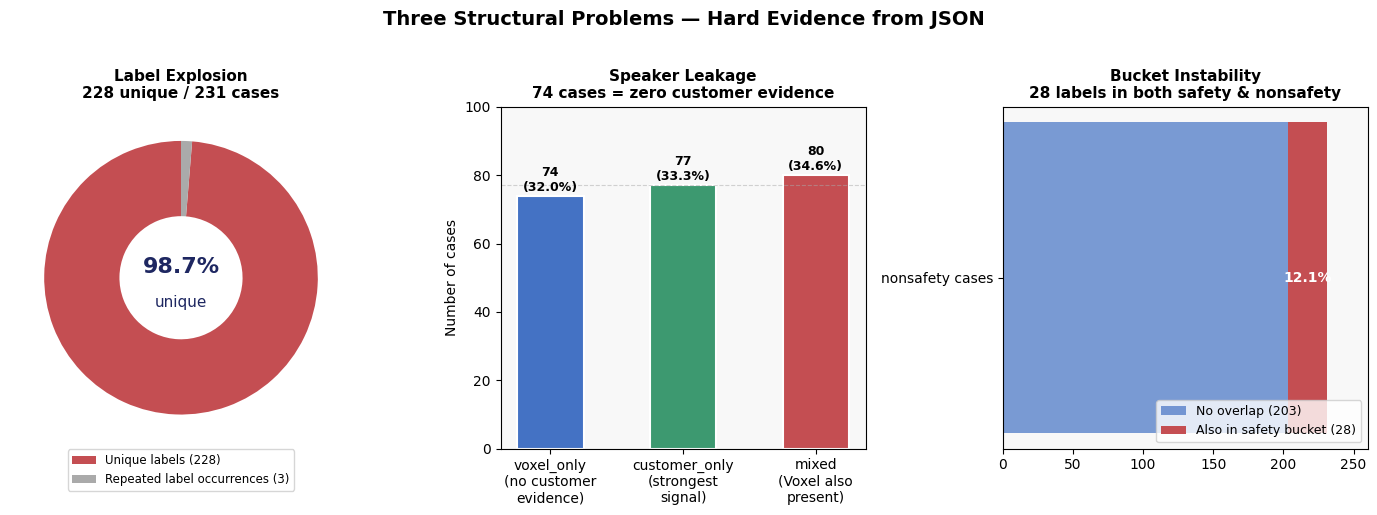

✓ saved: fig_structural_problems.png


In [9]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Three Structural Problems — Hard Evidence from JSON",
             fontsize=14, fontweight="bold", y=1.02)

C = {
    "red": "#C44E52",
    "gold": "#C8A84B",
    "blue": "#4472C4",
    "gray": "#AAAAAA",
    "navy": "#1E2761",
    "lgray": "#E8EDF5",
}

# Panel 1: Label explosion — clean 2-segment donut
ax = axes[0]
sizes = [228, 3]
colors = [C["red"], C["gray"]]
labels = ["Unique labels (228)", "Repeated label occurrences (3)"]
wedges, _ = ax.pie(sizes, colors=colors, startangle=90,
                   wedgeprops=dict(width=0.55))
ax.text(0, 0.08, "98.7%", ha="center", va="center",
        fontsize=16, fontweight="bold", color=C["navy"])
ax.text(0, -0.18, "unique", ha="center", va="center",
        fontsize=11, color=C["navy"])
ax.set_title("Label Explosion\n228 unique / 231 cases", fontsize=11, fontweight="bold")
ax.legend(wedges, labels, loc="lower center", fontsize=8.5,
          bbox_to_anchor=(0.5, -0.14), ncol=1)

# Panel 2: Speaker origin
ax2 = axes[1]
cats = ["voxel_only\n(no customer\nevidence)", "customer_only\n(strongest\nsignal)", "mixed\n(Voxel also\npresent)"]
vals = [74, 77, 80]
cols = [C["blue"], "#3D9970", C["red"]]
bars = ax2.bar(cats, vals, color=cols, width=0.5, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, vals):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 1.5,
             f"{val}\n({val/231*100:.1f}%)", ha="center", fontsize=9, fontweight="bold")
ax2.set_ylim(0, 100)
ax2.set_ylabel("Number of cases")
ax2.set_title("Speaker Leakage\n74 cases = zero customer evidence", fontsize=11, fontweight="bold")
ax2.axhline(231/3, color=C["gray"], linestyle="--", linewidth=0.8, alpha=0.5)
ax2.set_facecolor("#F8F8F8")

# Panel 3: Bucket instability
ax3 = axes[2]
total_ns = 231
overlap = 28
no_overlap = total_ns - overlap
ax3.barh(["nonsafety cases"], [no_overlap], color=C["blue"], alpha=0.7,
         label=f"No overlap ({no_overlap})")
ax3.barh(["nonsafety cases"], [overlap], left=[no_overlap], color=C["red"],
         label=f"Also in safety bucket ({overlap})")
ax3.set_xlim(0, 260)
ax3.set_title("Bucket Instability\n28 labels in both safety & nonsafety", fontsize=11, fontweight="bold")
ax3.legend(fontsize=9, loc="lower right")
ax3.text(no_overlap + overlap/2, 0, "12.1%", ha="center", va="center",
         fontsize=10, fontweight="bold", color="white")
ax3.set_facecolor("#F8F8F8")

plt.tight_layout()
plt.savefig("fig_structural_problems.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ saved: fig_structural_problems.png")

## Flow & Throughput — Supporting evidence

### Why this figure matters

Step 7 suggests that `flow_throughput` is one of the cleaner adjacent themes.  
This figure adds two extra checks.

The first panel shows how speaker mix changes over time.  
The second panel provides a comparison of customer evidence quality between topics.

### How to read it

In the time view, `flow_throughput` shows more customer presence after 2022.  
The sample is small, so I treat this as directional only.

In the theme comparison, `flow_throughput` does not lead on every metric.  
At the same time, it has fairly solid customer-side signals and remains clearly separated from the safety category.

### Takeaway

`flow_throughput` is not the strongest theme on any single metric.  
What stands out is the combination.



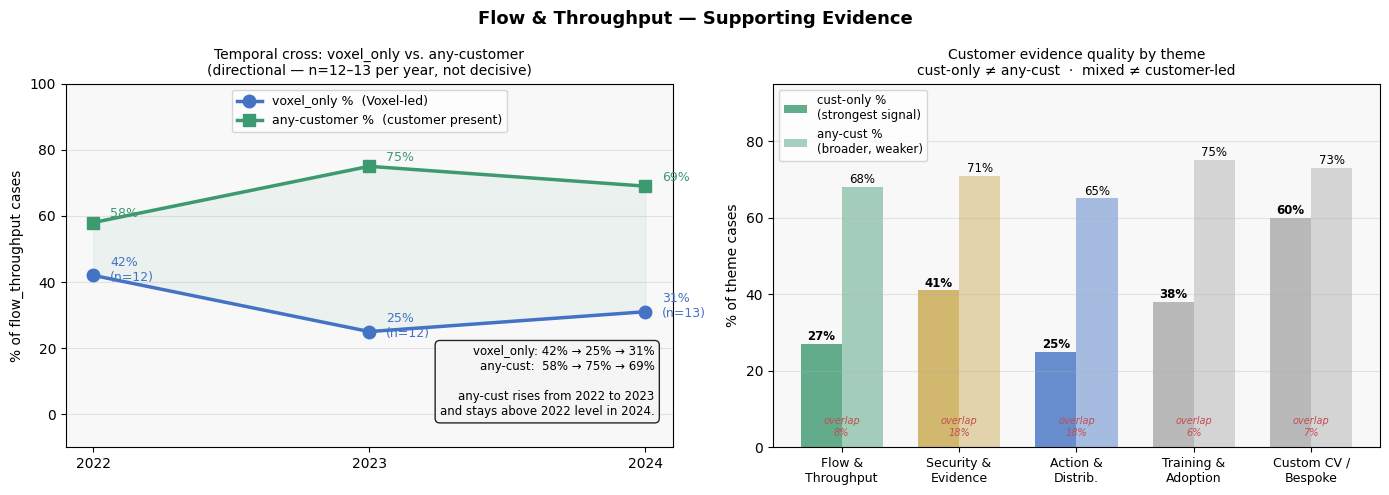

✓ saved: fig_flow_and_scorecard.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Flow & Throughput — Supporting Evidence", fontsize=13, fontweight="bold")

# Panel 1: Temporal trend
ax = axes[0]
years = ["2022", "2023", "2024"]
vo_pcts = [42, 25, 31]
ac_pcts = [58, 75, 69]
ns      = [12, 12, 13]

ax.plot(years, vo_pcts, "o-", color="#4472C4", linewidth=2.5,
        markersize=9, label="voxel_only %  (Voxel-led)")
ax.plot(years, ac_pcts, "s-", color="#3D9970", linewidth=2.5,
        markersize=9, label="any-customer %  (customer present)")

for yr, vo, ac, n in zip(years, vo_pcts, ac_pcts, ns):
    ax.annotate(f"{vo}%\n(n={n})", (yr, vo),
                textcoords="offset points", xytext=(12, -4),
                fontsize=9, color="#4472C4")
    ax.annotate(f"{ac}%", (yr, ac),
                textcoords="offset points", xytext=(12, 4),
                fontsize=9, color="#3D9970")

ax.fill_between(years, vo_pcts, ac_pcts, alpha=0.07, color="#3D9970")
ax.set_ylim(-10, 100)
ax.set_ylabel("% of flow_throughput cases")
ax.set_title("Temporal cross: voxel_only vs. any-customer\n"
             "(directional — n=12–13 per year, not decisive)", fontsize=10)
#ax.legend(fontsize=9)
ax.legend(fontsize=9, loc="upper center", bbox_to_anchor=(0.5, 1.0))
ax.grid(axis="y", alpha=0.3)
ax.set_facecolor("#F8F8F8")
ax.text(0.97, 0.08,
        "voxel_only: 42% → 25% → 31%\nany-cust:  58% → 75% → 69%\n\n"
        "any-cust rises from 2022 to 2023\nand stays above 2022 level in 2024.",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8.5,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#f5f5f5", alpha=0.85))

# Panel 2: Scorecard — cust-only vs any-cust per theme
ax2 = axes[1]
themes_short = ["Flow &\nThroughput", "Security &\nEvidence",
                "Action &\nDistrib.", "Training &\nAdoption", "Custom CV /\nBespoke"]
co_vals = [27, 41, 25, 38, 60]
ac_vals = [68, 71, 65, 75, 73]
theme_colors = ["#3D9970", "#C8A84B", "#4472C4", "#AAAAAA", "#AAAAAA"]

x = np.arange(len(themes_short))
w = 0.35
bars1 = ax2.bar(x - w/2, co_vals, w, label="cust-only %\n(strongest signal)",
                color=[c + "CC" for c in theme_colors])
bars2 = ax2.bar(x + w/2, ac_vals, w, label="any-cust %\n(broader, weaker)",
                color=theme_colors, alpha=0.45)

for bar, val in zip(bars1, co_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 1,
             f"{val}%", ha="center", fontsize=8.5, fontweight="bold")
for bar, val in zip(bars2, ac_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 1,
             f"{val}%", ha="center", fontsize=8.5)

ax2.set_xticks(x)
ax2.set_xticklabels(themes_short, fontsize=9)
ax2.set_ylabel("% of theme cases")
ax2.set_ylim(0, 95)
ax2.set_title("Customer evidence quality by theme\n"
              "cust-only ≠ any-cust  ·  mixed ≠ customer-led", fontsize=10)
ax2.legend(fontsize=8.5)
ax2.grid(axis="y", alpha=0.3)
ax2.set_facecolor("#F8F8F8")

# overlap annotation
ov_vals = [8, 18, 18, 6, 7]
for i, ov in enumerate(ov_vals):
    ax2.text(i, 3, f"overlap\n{ov}%", ha="center", fontsize=7,
             color="#C44E52", fontstyle="italic")

plt.tight_layout()
plt.savefig("fig_flow_and_scorecard.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ saved: fig_flow_and_scorecard.png")

## Workflow Improvement — Rule-based flags

### Why this figure matters

I do not want to review all 231 nonsafety cases in the same way.

This figure shows how a few simple rules can pull out the cases that need closer review first.

### How to read it

The left panel shows the three rule-based flags:

- `voxel_only`
- `safety_overlap`
- `exact_duplicate_label`

Together, they cover **93 of 231 cases**.

The right panel shows the review workflow.

I would fully review the flagged set first.  
Then I would spot-check a small share of the unflagged set to see what the rules miss.

### Consideration

It can only detect cases where the content is exactly the same.
It does not capture cases where the same idea is phrased differently.

The bigger problem is still label fragmentation, so review should happen at the cluster level, not one raw label at a time.

### Takeaway

A small set of simple rules cuts the first-pass review set down to **93 cases**, or about **40%** of the dataset.

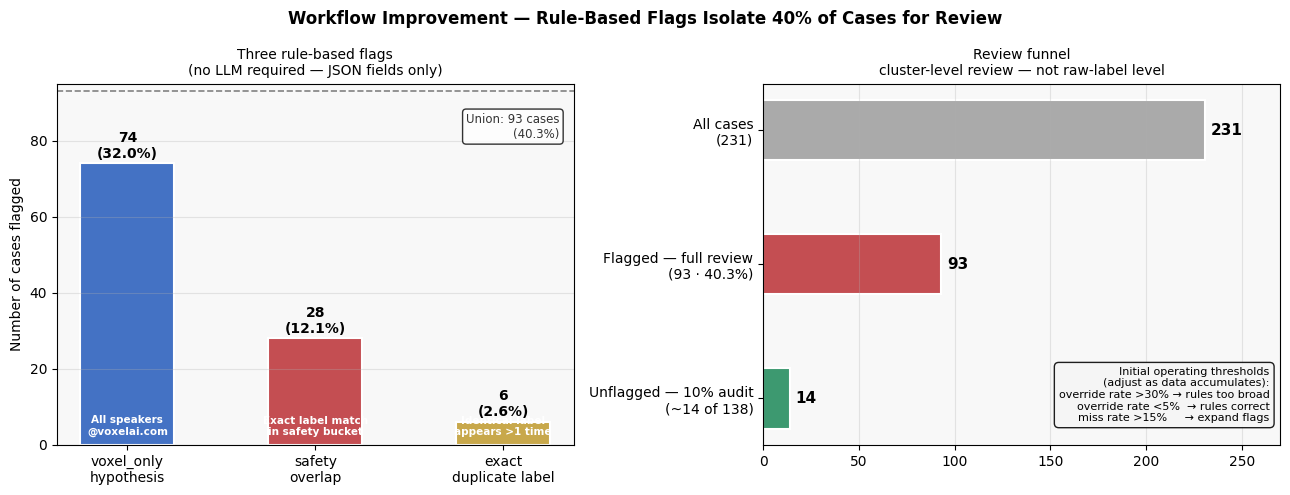

✓ saved: fig_workflow_flags.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Workflow Improvement — Rule-Based Flags Isolate 40% of Cases for Review",
             fontsize=12, fontweight="bold")

# Panel 1: Three flags breakdown
ax = axes[0]
flag_names  = ["voxel_only\nhypothesis", "safety\noverlap", "exact\nduplicate label"]
flag_vals   = [74, 28, 6]
flag_pcts   = [74/231*100, 28/231*100, 6/231*100]
flag_colors = ["#4472C4", "#C44E52", "#C8A84B"]

bars = ax.bar(flag_names, flag_vals, color=flag_colors, width=0.5,
              edgecolor="white", linewidth=1.5)
for bar, val, pct in zip(bars, flag_vals, flag_pcts):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1.5,
            f"{val}\n({pct:.1f}%)", ha="center", fontsize=10, fontweight="bold")

ax.set_ylim(0, 95)
ax.set_ylabel("Number of cases flagged")
ax.set_title("Three rule-based flags\n(no LLM required — JSON fields only)", fontsize=10)
ax.set_facecolor("#F8F8F8")
ax.grid(axis="y", alpha=0.3)

# union annotation
ax.axhline(93, color="#333333", linestyle="--", linewidth=1.2, alpha=0.6)
ax.text(2.30, 80, "Union: 93 cases\n(40.3%)", fontsize=8.5,
        color="#333333", ha="right", va="bottom",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# flag descriptions
descs = ["All speakers\n@voxelai.com", "Exact label match\nin safety bucket",
         "Identical label\nappears >1 time"]
for i, (bar, desc) in enumerate(zip(bars, descs)):
    ax.text(bar.get_x() + bar.get_width()/2, 2,
            desc, ha="center", va="bottom", fontsize=7.5,
            color="white", fontweight="bold")

# Panel 2: Review funnel
ax2 = axes[1]

# Funnel: all cases → flagged (full review) → unflagged (10% spot-check)
total_cases  = 231
flagged      = 93
unflagged    = 138
spot_check   = round(unflagged * 0.10)

categories   = ["All cases\n(231)", "Flagged — full review\n(93 · 40.3%)",
                "Unflagged — 10% audit\n(~14 of 138)"]
values       = [total_cases, flagged, spot_check]
bar_colors2  = ["#AAAAAA", "#C44E52", "#3D9970"]

bars2 = ax2.barh(categories, values, color=bar_colors2, height=0.45,
                 edgecolor="white", linewidth=1.5)
for bar, val in zip(bars2, values):
    ax2.text(val + 3, bar.get_y() + bar.get_height()/2,
             str(val), va="center", fontsize=11, fontweight="bold")

ax2.set_xlim(0, 270)
ax2.set_title("Review funnel\ncluster-level review — not raw-label level", fontsize=10)
ax2.set_facecolor("#F8F8F8")
ax2.grid(axis="x", alpha=0.3)
ax2.invert_yaxis()

# measurability note
ax2.text(0.98, 0.06,
         "Initial operating thresholds\n"
         "(adjust as data accumulates):\n"
         "override rate >30% → rules too broad\n"
         "override rate <5%  → rules correct\n"
         "miss rate >15%     → expand flags",
         transform=ax2.transAxes, ha="right", va="bottom", fontsize=8,
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#f5f5f5", alpha=0.88))

plt.tight_layout()
plt.savefig("fig_workflow_flags.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ saved: fig_workflow_flags.png")